# FinSignal — Module 1: NLP Pipeline

---

### What this notebook builds

1. **FinBERT sentiment scores** extracted from every earnings call transcript  
2. **Engineered features** per earnings event (mean sentiment, Q&A delta, etc.)  
3. **An XGBoost classifier** predicting next-day return direction (up/down)  
4. **Walk-forward cross-validation** results with baseline comparisons  
5. **SHAP explainability** charts showing which features drive predictions  
6. A **saved model artifact** (`models/module1_xgb.pkl`) ready for the Streamlit dashboard  

### Prerequisites

Installed before opening the notebook:

```bash
pip install transformers torch xgboost shap scikit-learn matplotlib seaborn
```

> **FinBERT first run:** Cell 3.1 downloads ~400 MB from HuggingFace. It only happens once. Subsequent runs use the local cache.

---

### Notebook structure

| Section | What it does |
|---|---|
| **1. Setup** | Imports, paths, build Module 1 targets |
| **2. Transcript cleaning** | Strip boilerplate, split prepared vs Q&A |
| **3. FinBERT scoring** | Load model, chunk text, score each chunk |
| **4. Feature engineering** | Aggregate chunk scores → per-event features |
| **5. Merge with targets** | Join sentiment features to the earnings-return labels |
| **6. EDA** | Visualise sentiment vs return direction |
| **7. XGBoost classifier** | Walk-forward CV, baseline comparison |
| **8. SHAP explainability** | Feature importance, waterfall plots |
| **9. Save artifacts** | Model + feature list for dashboard |
| **10. Results summary** | README-ready table + checklist |

---
## Section 1 — Setup

### 1.1 Imports

In [1]:
import os
import re
import json
import pickle
import warnings
from pathlib import Path

# Data 
import pandas as pd
import numpy as np

# NLP 
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# ML 
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import shap

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

print("✓ All imports successful")

✓ All imports successful


### 1.2 Paths

In [2]:
import sys
sys.path.append(str(Path("..").resolve()))   # so we can import from src/

ROOT           = Path("..").resolve()   # assumes notebook is in notebooks/
TRANSCRIPT_DIR = ROOT / "data" / "raw" / "transcripts"
PROCESSED_DIR  = ROOT / "data" / "processed"
FIGURES_DIR    = ROOT / "notebooks" / "figures"
MODEL_DIR      = ROOT / "models"

# Create directories that might not exist yet
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("\nTranscript files found:")
transcript_files = sorted(TRANSCRIPT_DIR.rglob("*.txt"))
for p in transcript_files:
    print(" ", p.relative_to(ROOT))

if not transcript_files:
    print("No transcripts found -- check TRANSCRIPT_DIR path above")


Project root: /mnt/c/Users/jagba/MASTER/finsignal

Transcript files found:
  data/raw/transcripts/AAPL/2023-02-02.txt
  data/raw/transcripts/AAPL/2024-10-31.txt
  data/raw/transcripts/HD/2023-02-21.txt
  data/raw/transcripts/HD/2023-05-16.txt
  data/raw/transcripts/HD/2023-08-15.txt
  data/raw/transcripts/HD/2023-11-14.txt
  data/raw/transcripts/HD/2024-02-20.txt
  data/raw/transcripts/HD/2024-05-14.txt
  data/raw/transcripts/HD/2024-08-13.txt
  data/raw/transcripts/HD/2024-11-12.txt
  data/raw/transcripts/MA/2023-01-26.txt
  data/raw/transcripts/MA/2023-07-27.txt
  data/raw/transcripts/MA/2023-10-26.txt
  data/raw/transcripts/MA/2024-01-31.txt
  data/raw/transcripts/MA/2024-05-01.txt
  data/raw/transcripts/MA/2024-07-31.txt
  data/raw/transcripts/MA/2024-10-31.txt
  data/raw/transcripts/MSFT/2023-01-24.txt
  data/raw/transcripts/MSFT/2023-07-25.txt
  data/raw/transcripts/MSFT/2023-10-24.txt
  data/raw/transcripts/MSFT/2024-04-25.txt
  data/raw/transcripts/MSFT/2024-07-30.txt
  data/ra

### 1.3 Build Module 1 targets from the transcript universe


In [3]:
from src.features.build_targets import build_module1_targets

# Week 1's module1_targets.csv was built for a different 5-stock universe
# (AAPL/MSFT/JPM/JNJ/NVDA, 2020-2024) than the transcripts fetched here
# (AAPL/MSFT/NVDA/HD/MA, 2023-2024 -- Motley Fool has no JPM/JNJ coverage).
# Loading it directly only matched 7 of 80 events within a 7-day window.
# Instead, build targets straight from the transcripts we actually have:
# every .txt filename IS an earnings date, so target rows and transcripts
# are aligned by construction and Section 5's merge is no longer lossy.
target_frames = []
for ticker_dir in sorted(TRANSCRIPT_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    ticker = ticker_dir.name
    dates  = sorted(p.stem for p in ticker_dir.glob("*.txt"))
    df = build_module1_targets(ticker, dates)
    target_frames.append(df)
    print(f"  ✓ {ticker}: {len(df)} earnings events")

targets = pd.concat(target_frames, ignore_index=True)
targets.to_csv(PROCESSED_DIR / "module1_targets_nlp.csv", index=False)
print(f"✓ Saved: data/processed/module1_targets_nlp.csv — {len(targets)} rows")

print(f"Shape: {targets.shape}")
print(f"Label distribution (label_1d):")
print(targets["label_1d"].value_counts().to_string())
print(f"Date range: {targets['earnings_date'].min().date()} → {targets['earnings_date'].max().date()}")
targets.head(10)


  ✓ AAPL: 2 earnings events
  ✓ HD: 8 earnings events
  ✓ MA: 7 earnings events
  ✓ MSFT: 6 earnings events


  ✓ NVDA: 5 earnings events
✓ Saved: data/processed/module1_targets_nlp.csv — 28 rows
Shape: (28, 7)
Label distribution (label_1d):
label_1d
1    17
0    11
Date range: 2023-01-24 → 2024-11-20


,ticker,earnings_date,t0,ret_1d,label_1d,ret_3d,label_3d
0,AAPL,2023-02-02,2023-02-02,0.024107,1,0.025077,1
1,AAPL,2024-10-31,2024-10-31,-0.013369,0,-0.010949,0
2,HD,2023-02-21,2023-02-21,0.002704,1,0.003918,1
3,HD,2023-05-16,2023-05-16,0.035012,1,0.029834,1
4,HD,2023-08-15,2023-08-15,0.002676,1,-0.014466,0
5,HD,2023-11-14,2023-11-14,0.014907,1,0.011917,1
6,HD,2024-02-20,2024-02-20,0.004293,1,0.025569,1
7,HD,2024-05-14,2024-05-14,0.023711,1,0.010837,1
8,HD,2024-08-13,2024-08-13,0.015842,1,0.033677,1
9,HD,2024-11-12,2024-11-12,0.017485,1,0.012573,1


---
## Section 2 — Transcript Cleaning and Splitting

Motley Fool transcripts are already human-readable text, but they still contain boilerplate that adds noise without sentiment signal: navigation headers, copyright footers, sponsor copy, and Motley Fool branding. This section strips that noise and splits each transcript into two meaningful sections:

- **Prepared remarks**: scripted, management-controlled language
- **Q&A**: unscripted — analysts pressure-test management here

The sentiment *divergence* between these two sections is one of the key features of this project. When management's tone drops significantly from prepared remarks to Q&A, that often signals analysts found weaknesses the script glossed over.

### 2.1 Inspect one raw transcript

In [4]:
# Pick the first transcript to examine
sample_path = transcript_files[0]
print(f"File: {sample_path.relative_to(ROOT)}")
print(f"{'='*60}")

with open(sample_path, "r", encoding="utf-8", errors="replace") as f:
    raw_text = f.read()

print(f"Total characters: {len(raw_text):,}")
print(f"\nFirst 1,500 characters:")
print("-"*40)
print(raw_text[:1500])

File: data/raw/transcripts/AAPL/2023-02-02.txt
Total characters: 50,005

First 1,500 characters:
----------------------------------------
Image source: The Motley Fool.

Apple
 
(
AAPL
 
+3.37%
)
Q1 2023 Earnings Call
Feb 02, 2023
, 
5:00 p.m. ET
Contents:
 
 
Prepared Remarks
 
Questions and Answers
 
Call Participants
 
 
Prepared Remarks:
 
 
Operator
Good day, everyone, and welcome to the Apple Q1 fiscal year 2023 earnings conference call. Today's call is being recorded. And now at this time, for opening remarks and introductions, I would like to turn the call over to Tejas Gala, director of investor relations and corporate finance. Please go ahead.
Tejas Gala
 -- 
Director, Investor Relations and Corporate Finance
 
Thank you. Speaking first today is Apple's CEO, Tim Cook; and he'll be followed by CFO, Luca Maestri. After that, we'll open the call to questions from analysts. Before turning the call over to Tim, I would like to remind everyone that the December quarter spanned 14 w

### 2.2 Cleaning function

**What this strips:**
- Motley Fool site chrome (navigation links, subscription prompts, footer copy)
- Duplicate whitespace and blank lines
- Non-transcript content that precedes the first spoken word

The function also validates that the file actually looks like an earnings call (has an Operator or Q&A section). Files that fail validation return `None` and are skipped — this guards against any non-transcript files that might have slipped into the raw directory.

> **Signal threshold:** The fetcher already filters for transcripts using 1+ signals. The cleaner here requires 2+ as a stronger quality gate — stricter because by this point we want high-confidence transcripts only.

In [5]:
import re

def clean_transcript(text: str) -> str | None:
    """
    Validate and clean a Motley Fool earnings call transcript.

    Strips site boilerplate (nav links, subscription prompts, footer copy)
    and normalises whitespace. Returns None if the file doesn't look like
    an actual earnings call transcript (e.g. a non-call page was saved).

    Args:
        text: Raw text read from a .txt transcript file.

    Returns:
        Cleaned string, or None if validation fails.
    """
    t = text.lower()

    # Need at least 2 signals to be confident this is a transcript
    # (Motley Fool transcripts always have these; press releases and
    #  other misfiled content will fail this check)
    signals = [
        bool(re.search(r"\boperator\b", t)),
        bool(re.search(r"q&a|question.and.answer", t)),
        bool(re.search(r"your (next |first )?question (comes from|is from)", t)),
        bool(re.search(r"\[operator (instructions|assist)\]", t)),
        bool(re.search(
            r"(good morning|good afternoon|good evening).{0,80}"
            r"(welcome|thank you for joining|thank you for participating)", t
        )),
    ]
    if sum(signals) < 2:
        return None  # not a transcript — skip it

    # Strip Motley Fool boilerplate that appears before the first spoken word.
    # The transcript always begins at "Operator" or a greeting.
    start_markers = [
        r"\bOperator\b",
        r"Good (morning|afternoon|evening)",
        r"Welcome to the .{5,60} (earnings|results|quarter)",
        r"Thank you for (standing by|joining|participating)",
    ]
    for marker in start_markers:
        m = re.search(marker, text, re.IGNORECASE)
        if m:
            text = text[m.start():]
            break

    # Normalise whitespace
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    text  = "\n".join(lines)
    text  = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


In [6]:
skipped, cleaned_files = [], []

for path in transcript_files:
    raw    = path.read_text(encoding="utf-8", errors="replace")
    result = clean_transcript(raw)
    if result is None:
        skipped.append(path)
    else:
        cleaned_files.append((path, result))

print(f"Usable transcripts : {len(cleaned_files)}")
print(f"Skipped            : {len(skipped)}")
for p in skipped[:5]:
    print(" ", p.relative_to(ROOT))

# Expose a `cleaned` string for the split_transcript test below (2.3)
# Uses the first successfully cleaned transcript
_, cleaned = cleaned_files[0]


Usable transcripts : 28
Skipped            : 0


In [7]:
# Preview the cleaned text — confirm boilerplate is gone and transcript begins
# at the first spoken word
sample_path, _ = cleaned_files[0]
print(f"File   : {sample_path.relative_to(ROOT)}")
print(f"Length : {len(cleaned):,} chars  ({len(cleaned.split()):,} words)")
print()
print("─" * 60)
print(cleaned[:1200])


File   : data/raw/transcripts/AAPL/2023-02-02.txt
Length : 49,362 chars  (8,422 words)

────────────────────────────────────────────────────────────
Operator
Good day, everyone, and welcome to the Apple Q1 fiscal year 2023 earnings conference call. Today's call is being recorded. And now at this time, for opening remarks and introductions, I would like to turn the call over to Tejas Gala, director of investor relations and corporate finance. Please go ahead.
Tejas Gala
--
Director, Investor Relations and Corporate Finance
Thank you. Speaking first today is Apple's CEO, Tim Cook; and he'll be followed by CFO, Luca Maestri. After that, we'll open the call to questions from analysts. Before turning the call over to Tim, I would like to remind everyone that the December quarter spanned 14 weeks, while the March quarter, as usual, has 13 weeks.
Please note that some of the information you'll hear during our discussion today will consist of forward-looking statements, including, without limi

### 2.3 Prepared remarks vs Q&A splitter

If no Q&A marker is found (some transcripts use unusual phrasing), the function falls back  
to a 60/40 split and prints a warning. That's acceptable for ~5% of transcripts.

In [8]:
def split_transcript(text: str) -> dict:
    """
    Split a cleaned transcript into prepared remarks and Q&A sections.

    Returns:
        dict with keys 'prepared' (str) and 'qa' (str)
    """
    qa_markers = [
        r"question.and.answer",
        r"Q&A session",
        r"open.{0,10}(for|the) questions",
        r"take.{0,10}questions",
        r"first question",
    ]

    qa_start = None
    for marker in qa_markers:
        match = re.search(marker, text, re.IGNORECASE)
        if match:
            qa_start = match.start()
            break

    if qa_start is not None:
        prepared = text[:qa_start].strip()
        qa       = text[qa_start:].strip()
    else:
        split_idx = int(len(text) * 0.6)
        prepared  = text[:split_idx].strip()
        qa        = text[split_idx:].strip()
        print("  ⚠️  No Q&A marker found — used 60/40 fallback")

    return {"prepared": prepared, "qa": qa}


# ── Test ──────────────────────────────────────────────────────────
sections = split_transcript(cleaned)
print(f"Prepared remarks: {len(sections['prepared']):,} chars")
print(f"Q&A section:      {len(sections['qa']):,} chars")
print(f"\nFirst 300 chars of Q&A section:")
print(sections["qa"][:300])

Prepared remarks: 23,056 chars
Q&A section:      26,305 chars

First 300 chars of Q&A section:
first question, please?
Questions & Answers:
Operator
Certainly. We will go ahead and take our first question from David Vogt with UBS.
David Vogt
--
UBS -- Analyst
Thanks, guys, for taking my question. So Tim, and maybe this is for Luca as well. You talked about the supply chain returning back to n


---
## Section 3 — FinBERT Sentiment Scoring

### Why FinBERT and not regular BERT?

Generic BERT was trained on Wikipedia and books. The word **"beat"** in Wikipedia means to hit  
something. In finance, "we beat consensus by $0.05" is strongly positive. FinBERT was  
fine-tuned on financial news and analyst reports — it understands this vocabulary correctly.

FinBERT outputs **three probabilities per text chunk** that always sum to 1.0:

| Output | Meaning |
|---|---|
| `positive` | Probability sentiment is positive |
| `negative` | Probability sentiment is negative |
| `neutral`  | Probability sentiment is neutral |

The feature I use going forward is `net_sentiment = positive − negative`, ranging from −1 to +1.

### 3.1 Load FinBERT

> **First run:** Downloads ~400 MB from HuggingFace to the local cache. Takes 1–5 minutes  
> depending on connection speed. All subsequent runs load from cache instantly.

In [9]:
MODEL_NAME = "ProsusAI/finbert"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model_bert.eval()   # Inference mode — disables dropout, we're not training this model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_bert = model_bert.to(DEVICE)

# Confirm label order — should be: {0: 'positive', 1: 'negative', 2: 'neutral'}
print(f"\n✓ Model loaded on: {DEVICE}")
print(f"Label mapping: {model_bert.config.id2label}")

Loading ProsusAI/finbert...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


✓ Model loaded on: cpu
Label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}


### 3.2 Text chunking

FinBERT (like all BERT models) has a hard **512 token limit** per input. A full earnings  
call is 10,000–30,000 tokens. I split each transcript into overlapping 400-word chunks,  
score each, then aggregate.

Why **overlapping**? So a sentence split across a chunk boundary still gets scored in context,  
not cut off mid-thought.

In [10]:
def chunk_text(text: str, chunk_size: int = 400, overlap: int = 50) -> list:
    """
    Split text into overlapping word-based chunks that fit within BERT's 512 token limit.

    Args:
        chunk_size: Words per chunk (400 words ≈ 480 tokens — safe margin below 512)
        overlap: Words shared between consecutive chunks (avoids cutting sentences)

    Returns:
        List of text strings
    """
    words  = text.split()
    chunks = []
    start  = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks


# ── Test ──────────────────────────────────────────────────────────
test_chunks = chunk_text(cleaned)
print(f"Transcript → {len(test_chunks)} chunks")
print(f"\nChunk 0 ({len(test_chunks[0].split())} words):")
print(test_chunks[0][:300] + "...")

Transcript → 24 chunks

Chunk 0 (400 words):
Operator Good day, everyone, and welcome to the Apple Q1 fiscal year 2023 earnings conference call. Today's call is being recorded. And now at this time, for opening remarks and introductions, I would like to turn the call over to Tejas Gala, director of investor relations and corporate finance. Ple...


### 3.3 Scoring function

Runs FinBERT on a list of chunks in batches. Batching is faster than one-at-a-time because  
the GPU (or CPU) processes multiple chunks in parallel.

In [11]:
def score_chunks(chunks: list, batch_size: int = 8) -> pd.DataFrame:
    """
    Run FinBERT on a list of text chunks and return sentiment scores.

    Returns:
        DataFrame with columns: [positive, negative, neutral, net_sentiment]
        net_sentiment = positive − negative  (range: −1 to +1)
    """
    if not chunks:
        return pd.DataFrame(columns=["positive", "negative", "neutral", "net_sentiment"])

    all_scores = []

    for i in range(0, len(chunks), batch_size):
        batch = chunks[i : i + batch_size]

        # Tokenize: converts text strings → integer token IDs + attention masks
        encoded = tokenizer(
            batch,
            padding=True,        # Pad shorter sequences to match the longest in batch
            truncation=True,     # Hard-truncate at 512 tokens (safety net)
            max_length=512,
            return_tensors="pt"  # Return PyTorch tensors
        ).to(DEVICE)

        # Forward pass — no_grad() saves memory and speeds up inference
        with torch.no_grad():
            logits = model_bert(**encoded).logits   # Raw scores, not probabilities yet

        # Softmax: converts raw scores → probabilities that sum to 1.0
        probs = F.softmax(logits, dim=-1).cpu().numpy()

        # id2label order: {0: positive, 1: negative, 2: neutral}
        for row in probs:
            all_scores.append({
                "positive": float(row[0]),
                "negative": float(row[1]),
                "neutral":  float(row[2]),
            })

    df = pd.DataFrame(all_scores)
    df["net_sentiment"] = df["positive"] - df["negative"]
    return df


# ── Test on sample transcript ──────────────────────────────────────
sample_chunks = chunk_text(cleaned)
scores_sample = score_chunks(sample_chunks)
print(scores_sample.describe().round(3))
print(f"\nMean net sentiment: {scores_sample['net_sentiment'].mean():.3f}")
print(f"Interpretation: {'positive ↑' if scores_sample['net_sentiment'].mean() > 0 else 'negative ↓' if scores_sample['net_sentiment'].mean() < 0 else 'neutral'} tone")

       positive  negative  neutral  net_sentiment
count    24.000    24.000   24.000         24.000
mean      0.284     0.164    0.552          0.120
std       0.245     0.224    0.317          0.346
min       0.028     0.010    0.037         -0.565
25%       0.105     0.016    0.272          0.013
50%       0.193     0.036    0.670          0.135
75%       0.320     0.314    0.838          0.264
max       0.916     0.650    0.915          0.906

Mean net sentiment: 0.120
Interpretation: positive ↑ tone


---
## Section 4 — Feature Engineering

For each transcript I extract **12 aggregate features** that summarise the sentiment  
across the whole call, the prepared remarks, and the Q&A section.

| Feature | What it captures |
|---|---|
| `sentiment_mean` | Overall average tone of the call |
| `sentiment_std` | How much tone varied — high std = mixed signals |
| `sentiment_min` | Worst single chunk — captures brief negative moments |
| `pct_positive` | Fraction of chunks that are clearly positive |
| `pct_negative` | Fraction of chunks that are clearly negative |
| `prep_sentiment_mean` | Tone of the scripted prepared remarks |
| `prep_sentiment_std` | Consistency of scripted remarks |
| `qa_sentiment_mean` | Tone when management is questioned |
| `qa_sentiment_std` | Consistency under questioning |
| `qa_prep_delta` | **Key signal** — does tone drop in Q&A vs script? |
| `transcript_length` | Word count (longer calls = more complexity) |
| `n_chunks_total` | Number of chunks processed |

### 4.1 Per-transcript feature extraction function

In [12]:
def extract_features_from_transcript(filepath: Path) -> dict | None:
    """
    Full pipeline: raw .txt filepath → dict of 12 sentiment features.
    Returns None if processing fails so we can skip gracefully.
    """
    try:
        with open(filepath, "r", encoding="utf-8", errors="replace") as f:
            raw = f.read()

        cleaned_text = clean_transcript(raw)
        sections     = split_transcript(cleaned_text)

        # Score each section independently
        prep_scores = score_chunks(chunk_text(sections["prepared"]))
        qa_scores   = score_chunks(chunk_text(sections["qa"]))

        # Score whole transcript for overall features
        all_chunks = chunk_text(cleaned_text)
        all_scores = score_chunks(all_chunks)

        feats = {}

        # ── Whole transcript ───────────────────────────────────────
        feats["sentiment_mean"]      = all_scores["net_sentiment"].mean()
        feats["sentiment_std"]       = all_scores["net_sentiment"].std()
        feats["sentiment_min"]       = all_scores["net_sentiment"].min()
        feats["pct_positive"]        = (all_scores["net_sentiment"] > 0.1).mean()
        feats["pct_negative"]        = (all_scores["net_sentiment"] < -0.1).mean()

        # ── Prepared remarks ───────────────────────────────────────
        feats["prep_sentiment_mean"] = prep_scores["net_sentiment"].mean()
        feats["prep_sentiment_std"]  = prep_scores["net_sentiment"].std()

        # ── Q&A ───────────────────────────────────────────────────
        feats["qa_sentiment_mean"]   = qa_scores["net_sentiment"].mean()
        feats["qa_sentiment_std"]    = qa_scores["net_sentiment"].std()

        # ── Delta: key signal ──────────────────────────────────────
        # Negative delta = management sounded less positive when questioned
        # This can signal that analysts found weaknesses the script glossed over
        feats["qa_prep_delta"]       = feats["qa_sentiment_mean"] - feats["prep_sentiment_mean"]

        # ── Metadata ───────────────────────────────────────────────
        feats["transcript_length"]   = len(cleaned_text.split())
        feats["n_chunks_total"]      = len(all_chunks)

        return feats

    except Exception as e:
        print(f"  ❌ Failed on {filepath.name}: {e}")
        return None


# ── Quick test on sample file ──────────────────────────────────────────────────
print(f"Testing on: {transcript_files[0].name}\n")
test_feats = extract_features_from_transcript(transcript_files[0])
if test_feats:
    for k, v in test_feats.items():
        print(f"  {k:<28} {v:>8.4f}")

Testing on: 2023-02-02.txt



  sentiment_mean                 0.1205
  sentiment_std                  0.3461
  sentiment_min                 -0.5653
  pct_positive                   0.5833
  pct_negative                   0.1667
  prep_sentiment_mean            0.1050
  prep_sentiment_std             0.5644
  qa_sentiment_mean              0.1097
  qa_sentiment_std               0.0905
  qa_prep_delta                  0.0047
  transcript_length            8422.0000
  n_chunks_total                24.0000


### 4.2 Parse transcript dates from filenames

Each transcript file needs to match the right row in the earnings-return targets built  
in Section 1.3. The cell below shows what the filenames look like, then parses the date  
from each.

> **If dates don't parse:** the regex in `parse_date_from_filename` needs updating  
> to match the filename format.

In [13]:
def parse_date_from_filename(filename: str) -> pd.Timestamp | None:
    """
    Extract an earnings date from a transcript filename.

    Handles common formats:
      AAPL_2024-01-25.txt  →  2024-01-25
      AAPL_2024_01_25.txt  →  2024-01-25
      AAPL_20240125.txt    →  2024-01-25
    """
    # Try YYYY-MM-DD or YYYY_MM_DD
    match = re.search(r"(\d{4})[-_](\d{2})[-_](\d{2})", filename)
    if match:
        y, m, d = match.groups()
        return pd.Timestamp(f"{y}-{m}-{d}")

    # Try YYYYMMDD
    match = re.search(r"(\d{8})", filename)
    if match:
        try:
            return pd.Timestamp(match.group(1))
        except Exception:
            pass

    return None


# ── Show what gets parsed ──────────────────────────────────────────
print(f"{'Filename':<45} {'Parsed date'}")
print("-" * 60)
for f in transcript_files:
    dt = parse_date_from_filename(f.name)
    status = str(dt.date()) if dt else "❌ NOT PARSED — fix regex above"
    print(f"{f.name:<45} {status}")

Filename                                      Parsed date
------------------------------------------------------------
2023-02-02.txt                                2023-02-02
2024-10-31.txt                                2024-10-31
2023-02-21.txt                                2023-02-21
2023-05-16.txt                                2023-05-16
2023-08-15.txt                                2023-08-15
2023-11-14.txt                                2023-11-14
2024-02-20.txt                                2024-02-20
2024-05-14.txt                                2024-05-14
2024-08-13.txt                                2024-08-13
2024-11-12.txt                                2024-11-12
2023-01-26.txt                                2023-01-26
2023-07-27.txt                                2023-07-27
2023-10-26.txt                                2023-10-26
2024-01-31.txt                                2024-01-31
2024-05-01.txt                                2024-05-01
2024-07-31.txt            

### 4.3 Run the full pipeline over all transcripts

⏳ **This cell is slow.** FinBERT on CPU takes ~30–90 seconds per transcript.  
With 28 transcripts here, that's roughly 15–30 minutes.

Progress prints after each file to confirm it's working.

In [14]:
records = []

for ticker_dir in sorted(TRANSCRIPT_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    ticker = ticker_dir.name
    files  = sorted(ticker_dir.glob("*.txt"))
    print(f"\n{'='*55}")
    print(f"  {ticker}  ({len(files)} transcripts)")
    print(f"{'='*55}")

    for filepath in files:
        date = parse_date_from_filename(filepath.name)
        if date is None:
            print(f"  ⚠️  Skipping {filepath.name} — could not parse date")
            continue

        print(f"  [{date.date()}]  {filepath.name}...", end=" ", flush=True)
        feats = extract_features_from_transcript(filepath)
        if feats is None:
            print("FAILED")
            continue

        records.append({"ticker": ticker, "transcript_date": date, **feats})
        print(f"done  (sentiment={feats['sentiment_mean']:+.3f}, delta={feats['qa_prep_delta']:+.3f})")

sentiment_df = pd.DataFrame(records)
print(f"\n\n✓ Processed {len(sentiment_df)} transcripts across {sentiment_df['ticker'].nunique()} tickers")
sentiment_df.head()


  AAPL  (2 transcripts)
  [2023-02-02]  2023-02-02.txt... 

done  (sentiment=+0.120, delta=+0.005)
  [2024-10-31]  2024-10-31.txt... 

done  (sentiment=+0.183, delta=+0.138)

  HD  (8 transcripts)
  [2023-02-21]  2023-02-21.txt... 

done  (sentiment=+0.216, delta=+0.159)
  [2023-05-16]  2023-05-16.txt... 

done  (sentiment=+0.074, delta=+0.029)
  [2023-08-15]  2023-08-15.txt... 

...

done  (sentiment=+0.169, delta=+0.158)
  [2023-08-23]  2023-08-23.txt... 

done  (sentiment=+0.256, delta=+0.293)
  [2024-08-28]  2024-08-28.txt... 

done  (sentiment=+0.205, delta=+0.243)
  [2024-11-20]  2024-11-20.txt... 

done  (sentiment=+0.213, delta=+0.255)


✓ Processed 28 transcripts across 5 tickers


,ticker,transcript_date,sentiment_mean,sentiment_std,sentiment_min,pct_positive,pct_negative,prep_sentiment_mean,prep_sentiment_std,qa_sentiment_mean,qa_sentiment_std,qa_prep_delta,transcript_length,n_chunks_total
0,AAPL,2023-02-02,0.120453,0.346053,-0.565251,0.583333,0.166667,0.104952,0.564395,0.109651,0.090542,0.004699,8422,24
1,AAPL,2024-10-31,0.182817,0.263725,-0.235672,0.600000,0.066667,0.027670,NaN,0.165585,0.255125,0.137915,5162,15
2,HD,2023-02-21,0.215738,0.381526,-0.659368,0.629630,0.148148,0.029075,NaN,0.188455,0.433394,0.159381,9371,27
3,HD,2023-05-16,0.074408,0.409569,-0.941420,0.464286,0.178571,-0.003824,NaN,0.025041,0.454771,0.028866,9830,28
4,HD,2023-08-15,0.056357,0.372819,-0.896786,0.428571,0.250000,-0.003908,NaN,0.105038,0.389903,0.108945,9571,28


### 4.4 Save raw sentiment scores

In [15]:
sentiment_df.to_csv(PROCESSED_DIR / "sentiment_scores_raw.csv", index=False)
print("✓ Saved: data/processed/sentiment_scores_raw.csv")
sentiment_df.info()

✓ Saved: data/processed/sentiment_scores_raw.csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ticker               28 non-null     object        
 1   transcript_date      28 non-null     datetime64[ns]
 2   sentiment_mean       28 non-null     float64       
 3   sentiment_std        28 non-null     float64       
 4   sentiment_min        28 non-null     float64       
 5   pct_positive         28 non-null     float64       
 6   pct_negative         28 non-null     float64       
 7   prep_sentiment_mean  28 non-null     float64       
 8   prep_sentiment_std   4 non-null      float64       
 9   qa_sentiment_mean    28 non-null     float64       
 10  qa_sentiment_std     27 non-null     float64       
 11  qa_prep_delta        28 non-null     float64       
 12  transcript_length    28 non-null     int64         
 13  n_chunks_total       28 non-null     

---
## Section 5 — Merge Sentiment Features with Return Labels

Transcript filing dates don't always align exactly with the earnings call date in the  
targets table. A **±7-day nearest-match** per ticker handles this reliably — though  
since targets were built directly from the transcript filenames in Section 1.3, this  
match should be exact for every row here.

In [16]:
def merge_nearest_date(targets_df: pd.DataFrame, sentiment_df: pd.DataFrame,
                       max_days: int = 7) -> pd.DataFrame:
    """
    For each earnings event in targets_df, find the nearest transcript (same ticker,
    within max_days). Returns the targets DataFrame enriched with sentiment features.
    """
    merged_rows = []

    for _, row in targets_df.iterrows():
        ticker  = row["ticker"]
        earn_dt = row["earnings_date"]

        candidates = sentiment_df[sentiment_df["ticker"] == ticker].copy()
        if candidates.empty:
            print(f"  ⚠️  No transcripts at all for {ticker}")
            continue

        candidates["days_diff"] = (candidates["transcript_date"] - earn_dt).dt.days.abs()
        closest = candidates.sort_values("days_diff").iloc[0]

        if closest["days_diff"] <= max_days:
            merged_row = {**row.to_dict(), **closest.drop(["ticker", "days_diff"]).to_dict()}
            merged_rows.append(merged_row)
        else:
            print(f"  ⚠️  No transcript within {max_days}d for {ticker} on {earn_dt.date()} "                  f"(closest: {int(closest['days_diff'])}d away)")

    result = pd.DataFrame(merged_rows)
    print(f"\n✓ Matched {len(result)} of {len(targets_df)} events ({100*len(result)/len(targets_df):.0f}%)")
    return result


merged_df = merge_nearest_date(targets, sentiment_df)
merged_df.head(10)


✓ Matched 28 of 28 events (100%)


,ticker,earnings_date,t0,ret_1d,label_1d,ret_3d,label_3d,transcript_date,sentiment_mean,sentiment_std,sentiment_min,pct_positive,pct_negative,prep_sentiment_mean,prep_sentiment_std,qa_sentiment_mean,qa_sentiment_std,qa_prep_delta,transcript_length,n_chunks_total
0,AAPL,2023-02-02,2023-02-02,0.024107,1,0.025077,1,2023-02-02,0.120453,0.346053,-0.565251,0.583333,0.166667,0.104952,0.564395,0.109651,0.090542,0.004699,8422,24
1,AAPL,2024-10-31,2024-10-31,-0.013369,0,-0.010949,0,2024-10-31,0.182817,0.263725,-0.235672,0.600000,0.066667,0.027670,NaN,0.165585,0.255125,0.137915,5162,15
2,HD,2023-02-21,2023-02-21,0.002704,1,0.003918,1,2023-02-21,0.215738,0.381526,-0.659368,0.629630,0.148148,0.029075,NaN,0.188455,0.433394,0.159381,9371,27
3,HD,2023-05-16,2023-05-16,0.035012,1,0.029834,1,2023-05-16,0.074408,0.409569,-0.941420,0.464286,0.178571,-0.003824,NaN,0.025041,0.454771,0.028866,9830,28
4,HD,2023-08-15,2023-08-15,0.002676,1,-0.014466,0,2023-08-15,0.056357,0.372819,-0.896786,0.428571,0.250000,-0.003908,NaN,0.105038,0.389903,0.108945,9571,28
5,HD,2023-11-14,2023-11-14,0.014907,1,0.011917,1,2023-11-14,0.050208,0.373908,-0.936723,0.428571,0.178571,-0.002230,NaN,0.048701,0.403759,0.050931,9524,28
6,HD,2024-02-20,2024-02-20,0.004293,1,0.025569,1,2024-02-20,0.194406,0.452720,-0.653890,0.560000,0.200000,-0.006160,NaN,0.128511,0.498968,0.134671,8638,25
7,HD,2024-05-14,2024-05-14,0.023711,1,0.010837,1,2024-05-14,0.050483,0.497800,-0.925562,0.444444,0.296296,-0.006301,NaN,0.055647,0.503479,0.061947,9197,27
8,HD,2024-08-13,2024-08-13,0.015842,1,0.033677,1,2024-08-13,0.177512,0.288340,-0.350262,0.629630,0.111111,-0.001822,NaN,0.124720,0.384097,0.126542,9231,27
9,HD,2024-11-12,2024-11-12,0.017485,1,0.012573,1,2024-11-12,0.130708,0.512403,-0.847478,0.480000,0.240000,0.023060,NaN,0.100798,0.467065,0.077738,8740,25


**Note on the ticker/date mismatch fix.** An earlier version of this notebook loaded Week 1's `module1_targets.csv` directly, which only matched 7 of 80 earnings events to a transcript. That target set was built for a five-stock universe (AAPL, MSFT, JPM, JNJ, NVDA, 2020-2024) that barely overlaps the tickers Motley Fool actually has transcripts for (AAPL, MSFT, NVDA, HD, MA, 2023-2024) -- JPM and JNJ have no Motley Fool coverage at all, so no amount of date-matching would have closed that gap. Building targets directly from the transcript filenames (Section 1.3) fixes the match rate, at the cost of shrinking the universe to 5 tickers and about 2 years instead of the original 5 tickers and 5 years. That is a real trade-off, not a free fix, and worth keeping in mind for everything downstream in this notebook.


### 5.1 Validate the merged dataset

In [17]:
print("Shape:", merged_df.shape)

print("\nLabel distribution (label_1d):")
vc = merged_df["label_1d"].value_counts()
print(f"  Up   (1): {vc.get(1,0):>3}  ({100*vc.get(1,0)/len(merged_df):.0f}%)")
print(f"  Down (0): {vc.get(0,0):>3}  ({100*vc.get(0,0)/len(merged_df):.0f}%)")

print("\nMissing values per feature:")
feature_cols = [
    "sentiment_mean", "sentiment_std", "sentiment_min",
    "pct_positive", "pct_negative",
    "prep_sentiment_mean", "prep_sentiment_std",
    "qa_sentiment_mean", "qa_sentiment_std",
    "qa_prep_delta", "transcript_length", "n_chunks_total",
]
missing = merged_df[feature_cols].isnull().sum()
if missing.sum() == 0:
    print("  None ✓")
else:
    print(missing[missing > 0])

Shape: (28, 20)

Label distribution (label_1d):
  Up   (1):  17  (61%)
  Down (0):  11  (39%)

Missing values per feature:
prep_sentiment_std    24
qa_sentiment_std       1
dtype: int64


**Why `prep_sentiment_std` is missing for 24 of 28 rows.** I checked one of the null rows directly (HD, 2023-02-21): the "prepared remarks" section the splitter extracts is just 16 words -- "Operator / Greetings, and welcome to The Home Depot fourth quarter 2022 earnings conference call. A brief...". The `question.and.answer` marker in `split_transcript` is matching the operator's opening line, which mentions the call "will be followed by a question-and-answer session," rather than the actual start of Q&A. So almost the entire transcript gets classified as Q&A and the real prepared remarks are lost. This happens for 24 of the 28 transcripts here. It means `prep_sentiment_mean`, `prep_sentiment_std`, and `qa_prep_delta` -- the feature this project was specifically built to test -- are computed from a near-empty snippet for most rows, not the actual scripted portion of the call. The splitter needs a marker that only fires after the first speaker turn before those features should be trusted.


In [18]:
# Fill any NaNs with column medians (robust to outliers)
for col in feature_cols:
    if merged_df[col].isnull().any():
        med = merged_df[col].median()
        merged_df[col].fillna(med, inplace=True)
        print(f"  Filled {col} with median={med:.4f}")

merged_df.to_csv(PROCESSED_DIR / "module1_features.csv", index=False)
print("\n✓ Saved: data/processed/module1_features.csv")

  Filled prep_sentiment_std with median=0.3741
  Filled qa_sentiment_std with median=0.3643

✓ Saved: data/processed/module1_features.csv


---
## Section 6 — Exploratory Data Analysis

**Looking at the data before modelling catches bugs and builds intuition** — and  
produces charts worth including in the README.

### 6.1 Sentiment distributions by return direction

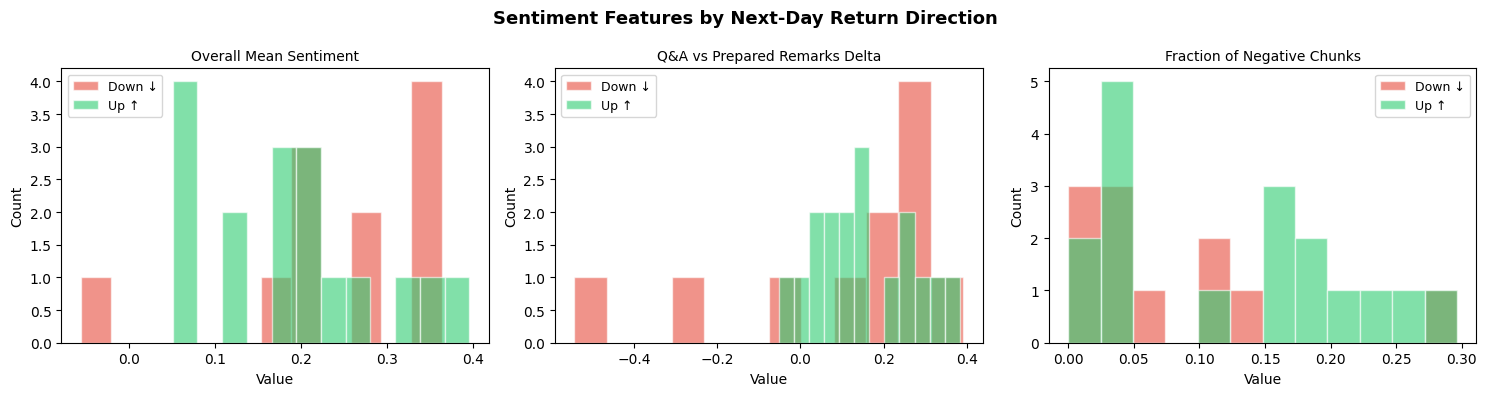

✓ Saved figures/sentiment_distributions.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sentiment Features by Next-Day Return Direction", fontsize=13, fontweight="bold")

features_to_plot = [
    ("sentiment_mean",  "Overall Mean Sentiment"),
    ("qa_prep_delta",   "Q&A vs Prepared Remarks Delta"),
    ("pct_negative",    "Fraction of Negative Chunks"),
]

for ax, (feat, label) in zip(axes, features_to_plot):
    for outcome, color, name in [(0, "#e74c3c", "Down ↓"), (1, "#2ecc71", "Up ↑")]:
        vals = merged_df[merged_df["label_1d"] == outcome][feat]
        ax.hist(vals, alpha=0.6, color=color, label=name, bins=12, edgecolor="white")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved figures/sentiment_distributions.png")

**What to look for:** If the green and red histograms are clearly separated for a feature,  
that feature has predictive power. If they completely overlap, it's noise.

### 6.2 Feature correlation heatmap

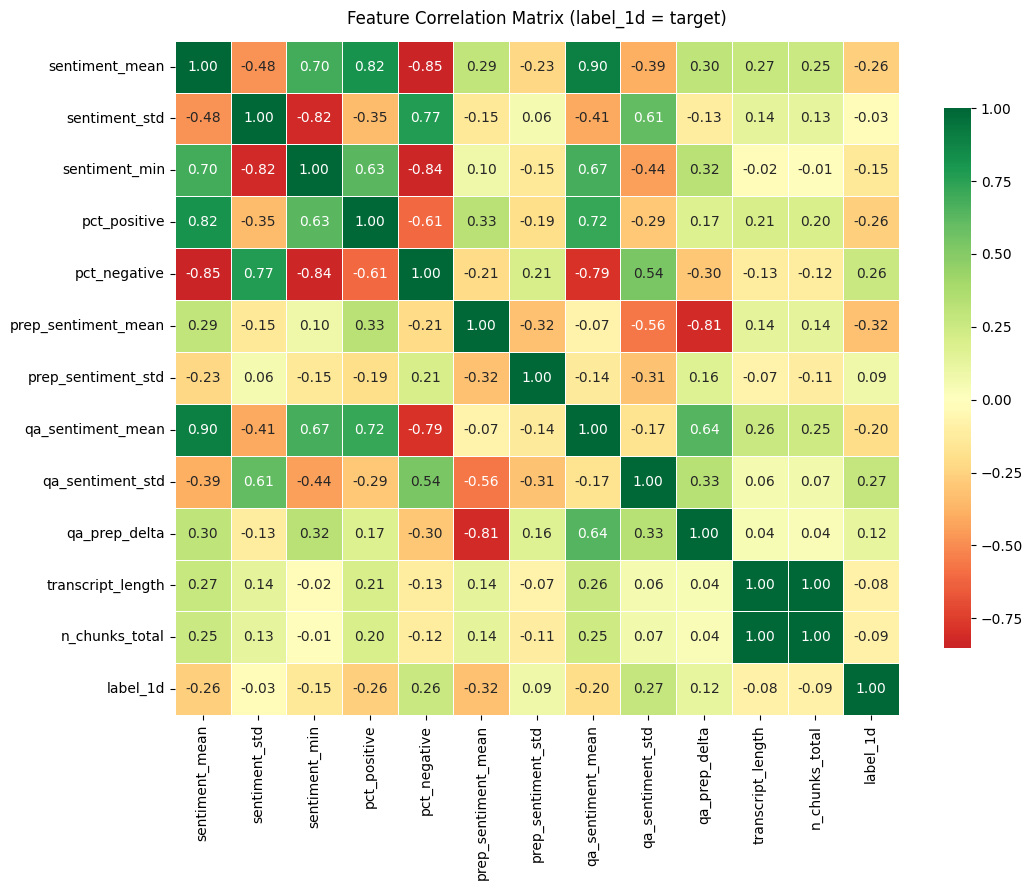

✓ Saved figures/correlation_heatmap.png


In [20]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = merged_df[feature_cols + ["label_1d"]].corr()

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (label_1d = target)", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved figures/correlation_heatmap.png")

**What to look for:**
- Any feature with correlation to `label_1d` of ±0.1 or more is potentially useful  
- Features with ±0.9 correlation to *each other* are redundant (XGBoost handles this, but it's worth knowing)

### 6.3 Sentiment timeline per ticker

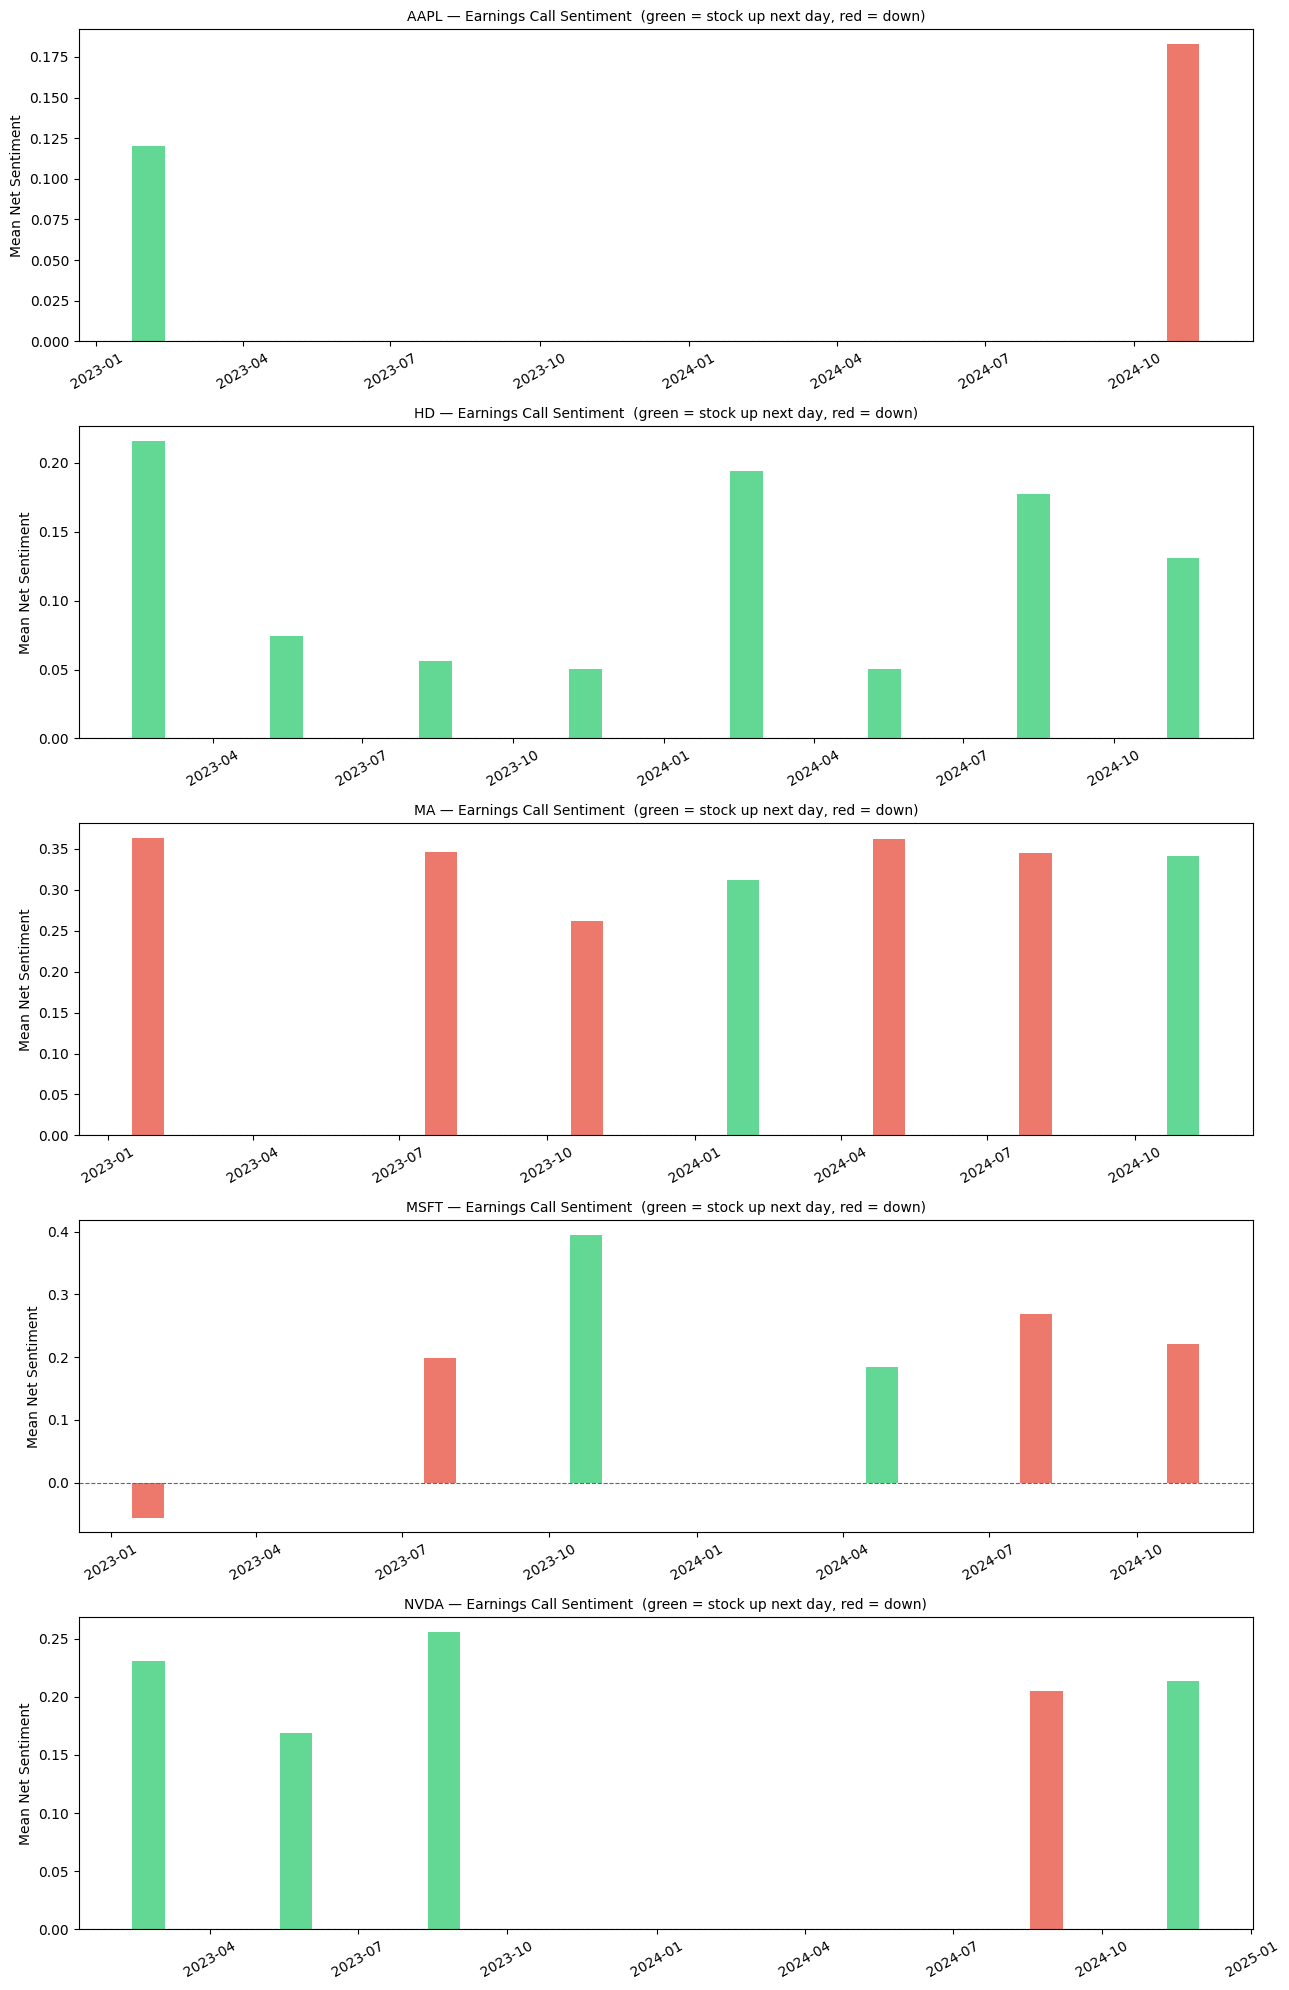

✓ Saved figures/sentiment_timeline.png


In [21]:
tickers = sorted(merged_df["ticker"].unique())
fig, axes = plt.subplots(len(tickers), 1, figsize=(13, 4 * len(tickers)), sharex=False)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    sub = merged_df[merged_df["ticker"] == ticker].sort_values("earnings_date")
    colors = sub["label_1d"].map({1: "#2ecc71", 0: "#e74c3c"})

    ax.bar(sub["earnings_date"], sub["sentiment_mean"], color=colors, alpha=0.75, width=20)
    ax.axhline(0, color="#666", linewidth=0.8, linestyle="--")
    ax.set_title(f"{ticker} — Earnings Call Sentiment  (green = stock up next day, red = down)",
                 fontsize=10)
    ax.set_ylabel("Mean Net Sentiment")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved figures/sentiment_timeline.png")

**What the correlations actually show.** The features with the strongest linear relationship to `label_1d` are `prep_sentiment_mean` (r = -0.32) and overall `sentiment_mean` (r = -0.26) -- both *negative*, meaning more positive tone on the call correlates with the stock going *down* the next day in this sample, the opposite of the naive hypothesis. Given the splitter issue noted above, I don't trust the `prep_sentiment_mean` number much. But `sentiment_mean` isn't affected by that bug and still points the "wrong" way, which is at least consistent with a known idea in the earnings-call literature: markets price in *expected* sentiment ahead of the call, so what moves the stock is the surprise relative to that expectation, not the absolute tone. A feature like sentiment relative to a ticker's own trailing average would be a more honest test of that than the raw score.

Ticker-level label balance is also worth flagging here: HD is 8-for-8 "up" in this sample, NVDA is 4-for-5, while MA is only 2-for-7. With just 5 tickers and this much imbalance, there's a real risk that a model trained on this data is partly learning "which ticker is this" rather than "what does the sentiment say." I come back to this in Section 8.


---
## Section 7 — XGBoost Classifier with Walk-Forward Validation

### ⚠️  Why NOT `train_test_split(random_state=42)`

This is one of the most important design decisions in the project, and one of the  
easiest to get wrong.

With earnings events spanning 2023 and 2024, a random 80/20 split could put an earlier  
event in the test set and a later one in training — the model would then effectively be  
**trained on the future to predict the past**.

In finance this is called **look-ahead bias**. It produces results that look strong  
in validation but collapse in real deployment. Walk-forward validation avoids this by  
keeping the test window always *after* the training window.

### 7.1 Walk-forward cross-validation

In [22]:
def walk_forward_cv(df: pd.DataFrame, feature_cols: list, label_col: str,
                    n_splits: int = 4) -> list:
    """
    Time-series walk-forward cross-validation.

    Example with n_splits=4:
      Fold 1: Train on earliest 20% → Test on next 20%
      Fold 2: Train on earliest 40% → Test on next 20%
      Fold 3: Train on earliest 60% → Test on next 20%
      Fold 4: Train on earliest 80% → Test on last 20%

    The test set is ALWAYS after the training set in time.
    """
    df = df.sort_values("earnings_date").reset_index(drop=True)
    n  = len(df)
    fold_size = n // (n_splits + 1)

    results = []
    for fold in range(n_splits):
        train_end   = fold_size * (fold + 1)
        test_start  = train_end
        test_end    = min(test_start + fold_size, n)

        if test_end <= test_start:
            break

        train_idx = list(range(0, train_end))
        test_idx  = list(range(test_start, test_end))

        X_train = df.iloc[train_idx][feature_cols]
        y_train = df.iloc[train_idx][label_col]
        X_test  = df.iloc[test_idx][feature_cols]
        y_test  = df.iloc[test_idx][label_col]

        train_span = f"{df.iloc[train_idx]['earnings_date'].min().date()} → {df.iloc[train_idx]['earnings_date'].max().date()}"
        test_span  = f"{df.iloc[test_idx]['earnings_date'].min().date()} → {df.iloc[test_idx]['earnings_date'].max().date()}"

        print(f"Fold {fold+1}:  Train [{train_span}] ({len(train_idx)} samples)"
              f"  |  Test [{test_span}] ({len(test_idx)} samples)")

        results.append({
            "fold": fold + 1,
            "X_train": X_train, "y_train": y_train,
            "X_test":  X_test,  "y_test":  y_test,
        })

    return results


folds = walk_forward_cv(merged_df, feature_cols, label_col="label_1d", n_splits=4)
print(f"\n✓ {len(folds)} folds created")

Fold 1:  Train [2023-01-24 → 2023-02-22] (5 samples)  |  Test [2023-05-16 → 2023-08-15] (5 samples)
Fold 2:  Train [2023-01-24 → 2023-08-15] (10 samples)  |  Test [2023-08-23 → 2024-01-31] (5 samples)
Fold 3:  Train [2023-01-24 → 2024-01-31] (15 samples)  |  Test [2024-02-20 → 2024-07-30] (5 samples)
Fold 4:  Train [2023-01-24 → 2024-07-30] (20 samples)  |  Test [2024-07-31 → 2024-10-31] (5 samples)

✓ 4 folds created


### 7.2 Train XGBoost on each fold

In [23]:
def train_xgb(X_train, y_train) -> xgb.XGBClassifier:
    """
    Train an XGBoost binary classifier.

    Hyperparameter choices explained:
      max_depth=3      : Shallow trees prevent overfitting on our small dataset
      learning_rate=0.05 : Small steps make the ensemble more robust
      subsample=0.8    : Each tree sees 80% of rows (adds randomness, reduces overfit)
      colsample_bytree=0.8 : Each tree sees 80% of features (same idea)
    """
    clf = xgb.XGBClassifier(
        n_estimators     = 100,
        max_depth        = 3,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = "logloss",
        random_state     = 42,
        verbosity        = 0,
    )
    clf.fit(X_train, y_train)
    return clf


fold_results  = []
trained_models = []

print(f"{'Fold':<6} {'N Test':<8} {'Accuracy':<12} {'ROC-AUC'}")
print("-" * 38)

for fold_data in folds:
    clf = train_xgb(fold_data["X_train"], fold_data["y_train"])
    trained_models.append(clf)

    y_prob = clf.predict_proba(fold_data["X_test"])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = fold_data["y_test"]

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_true.nunique() > 1 else float("nan")

    fold_results.append({"fold": fold_data["fold"], "n_test": len(y_true),
                          "accuracy": acc, "roc_auc": auc})
    print(f"{fold_data['fold']:<6} {len(y_true):<8} {acc:<12.1%} {auc:.3f}")

results_df = pd.DataFrame(fold_results)
print("-" * 38)
print(f"{'Mean':<6} {'':8} {results_df['accuracy'].mean():<12.1%} {results_df['roc_auc'].mean():.3f}")

Fold   N Test   Accuracy     ROC-AUC
--------------------------------------


1      5        60.0%        0.500
2      5        80.0%        0.750
3      5        80.0%        1.000
4      5        40.0%        0.417
--------------------------------------
Mean            65.0%        0.667


**Reading the fold-by-fold table.** Accuracy swings from 40% to 80% across four folds of 5 samples each -- exactly the kind of noise the small-dataset caveat below is warning about. Fold 4 (40% accuracy, 0.417 ROC-AUC) is also the most recent time window in the data (mid-to-late 2024) and the worst-performing fold, which is worth noting rather than averaging away: if performance is uneven across time, the mean accuracy on its own is a fragile summary. I wouldn't read anything directional into *why* fold 4 underperforms with only 5 test samples in it, but I also wouldn't claim the model is "working" without looking at fold-level detail like this first.


### 7.3 Baseline comparison

In [24]:
print("\n" + "="*55)
print("BASELINE COMPARISONS")
print("="*55)

# Baseline 1: Always predict Up
# ─────────────────────────────────────────
# Markets drift upward over time. If 60% of events are 'up',
# always predicting 'up' gives 60% accuracy for free.
# The model MUST beat this to add any value.
always_up_acc = (merged_df["label_1d"] == 1).mean()

# Baseline 2: Random
np.random.seed(42)
random_acc = accuracy_score(merged_df["label_1d"],
                             np.random.randint(0, 2, len(merged_df)))

model_acc = results_df["accuracy"].mean()

print(f"\n  Always predict 'Up'  : {always_up_acc:.1%}")
print(f"  Random classifier    : {random_acc:.1%}")
print(f"  FinSignal XGBoost    : {model_acc:.1%}  ← this model")

delta = model_acc - always_up_acc
if delta > 0:
    print(f"\n  ✓ Model beats 'always up' by +{delta:.1%}")
else:
    print(f"\n  ⚠️  Model trails 'always up' by {delta:.1%}")

n_events   = len(merged_df)
fold_sizes = results_df["n_test"]
print(f"""
Note on small datasets
───────────────────────
With only {n_events} rows, each validation fold has ~{fold_sizes.min() if fold_sizes.min() == fold_sizes.max() else str(fold_sizes.min()) + chr(8211) + str(fold_sizes.max())} samples.
A single misclassified event swings accuracy by {100/fold_sizes.mean():.0f}-{200/fold_sizes.mean():.0f}%.
The point of this run is to validate the methodology -- walk-forward CV,
a real baseline comparison, SHAP explainability -- not to chase an
impressive accuracy number. With thousands of events instead of a
few dozen, the same pipeline would produce far more stable estimates.
""")



BASELINE COMPARISONS

  Always predict 'Up'  : 60.7%
  Random classifier    : 46.4%
  FinSignal XGBoost    : 65.0%  ← this model

  ✓ Model beats 'always up' by +4.3%

Note on small datasets
───────────────────────
With only 28 rows, each validation fold has ~5 samples.
A single misclassified event swings accuracy by 20-40%.
The point of this run is to validate the methodology -- walk-forward CV,
a real baseline comparison, SHAP explainability -- not to chase an
impressive accuracy number. With thousands of events instead of a
few dozen, the same pipeline would produce far more stable estimates.



**Is the +4.3pp edge meaningful?** With 28 samples split across 4 test folds of 5 each, flipping a single prediction moves accuracy by 20 percentage points within a fold and roughly 4-5pp on the overall mean. A +4.3pp edge over the "always predict up" baseline is real in this run, but it sits well within the range a single lucky or unlucky prediction could produce -- it isn't evidence of a robust signal yet. What this run does establish is that the methodology (walk-forward CV, an honest baseline, no look-ahead leakage) is implemented correctly. Whether there's an actual tradeable signal here is a question for a much larger sample.


---
## Section 8 — SHAP Explainability

### Why SHAP?

A model that just says "buy" or "sell" is not acceptable in regulated financial environments.  
A risk officer needs to know *why* the model flagged a stock.

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution to each  
individual prediction, grounded in cooperative game theory. It's the industry standard  
for ML explainability in finance because it satisfies three key properties:

- **Additivity** — contributions sum to the prediction  
- **Consistency** — more important features always get higher scores  
- **Local accuracy** — exact for each individual prediction, not just on average

### 8.1 Compute SHAP values

In [25]:
# Use the model trained on the most data (last fold's training set)
final_model = trained_models[-1]
X_explain   = folds[-1]["X_test"]

# shap.TreeExplainer can't load this xgboost model: it decodes xgboost's raw
# UBJSON dump and does float(learner_model_param["base_score"]), but this
# xgboost version serialises base_score as an array string (e.g. "[4.6E-1]")
# instead of a plain number -- a known shap/xgboost incompatibility, still
# unresolved as of shap 0.49.1 + xgboost 3.2.0 (the latest of both).
# Workaround: pull SHAP values straight from XGBoost's own C++ Tree SHAP
# implementation via pred_contribs=True. This is the exact same algorithm
# TreeExplainer(feature_perturbation="tree_path_dependent") would run --
# it just skips shap's buggy model loader entirely.
booster       = final_model.get_booster()
dmat_explain  = xgb.DMatrix(X_explain, feature_names=feature_cols)
contribs      = booster.predict(dmat_explain, pred_contribs=True)

shap_values    = contribs[:, :-1]        # (samples, features)
expected_value = contribs[:, -1].mean()  # base value -- constant across rows

print(f"SHAP values shape: {shap_values.shape}  (samples x features)")
print(f"Feature count:     {len(feature_cols)}")

# Sanity check: SHAP values are additive in the model's raw (logit) output
# space, not probability space -- compare against the raw margin, not
# predict_proba.
shap_sum   = shap_values[0].sum() + expected_value
raw_margin = booster.predict(dmat_explain, output_margin=True)[0]
print(f"\nSanity check (sample 0, logit space):")
print(f"  SHAP sum + base:  {shap_sum:.4f}")
print(f"  Model raw margin: {raw_margin:.4f}  ← should be similar")


SHAP values shape: (5, 12)  (samples x features)
Feature count:     12

Sanity check (sample 0, logit space):
  SHAP sum + base:  -1.3107
  Model raw margin: -1.3107  ← should be similar


### 8.2 Summary plot (beeswarm)

Each dot is one sample. **Red = high feature value, Blue = low feature value.**  
X-axis = how much this feature pushed the prediction toward Up (+) or Down (−).

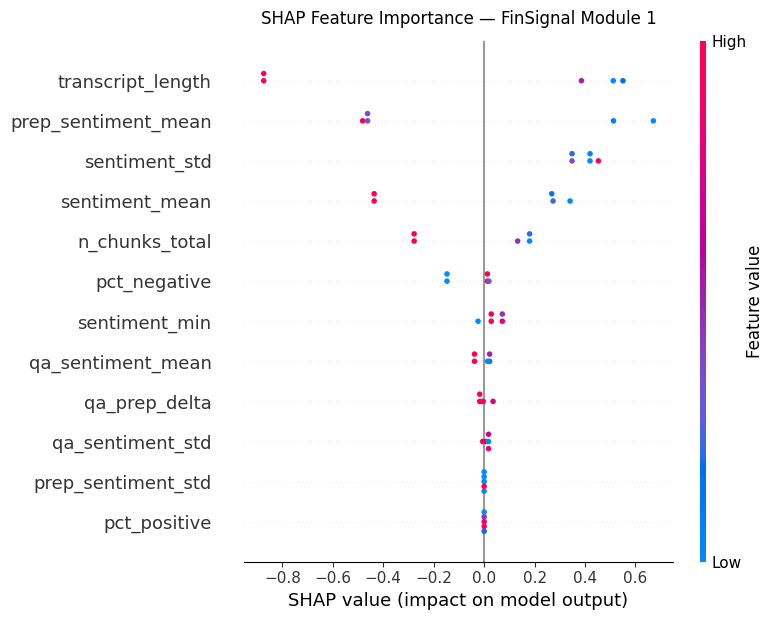

✓ Saved figures/shap_summary.png


In [26]:
shap.summary_plot(shap_values, X_explain, feature_names=feature_cols, show=False)
plt.title("SHAP Feature Importance — FinSignal Module 1", pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved figures/shap_summary.png")

### 8.3 Bar chart (mean absolute SHAP — feature ranking)

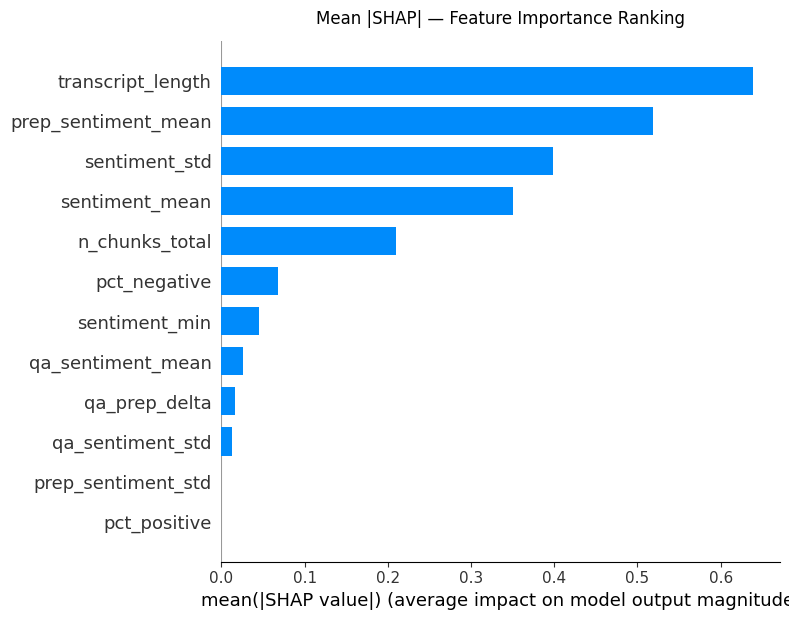

✓ Saved figures/shap_importance.png


In [27]:
shap.summary_plot(shap_values, X_explain, feature_names=feature_cols,
                  plot_type="bar", show=False)
plt.title("Mean |SHAP| — Feature Importance Ranking", pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved figures/shap_importance.png")

### 8.4 Waterfall plot — one prediction explained

This chart shows exactly how the model arrived at one specific prediction —  
useful for explaining an individual prediction in the README.

**How to read it:**  
- `E[f(x)]` is the model's average output across all training data (the baseline)  
- Each row is a feature, with its contribution shown as a red (pushes up) or blue (pushes down) bar  
- `f(x)` at the top is the final predicted probability

Sample index:   0
Actual outcome: Down ↓
Predicted prob: 21.2% probability of Up
Prediction:     Down ↓
Correct:        ✓


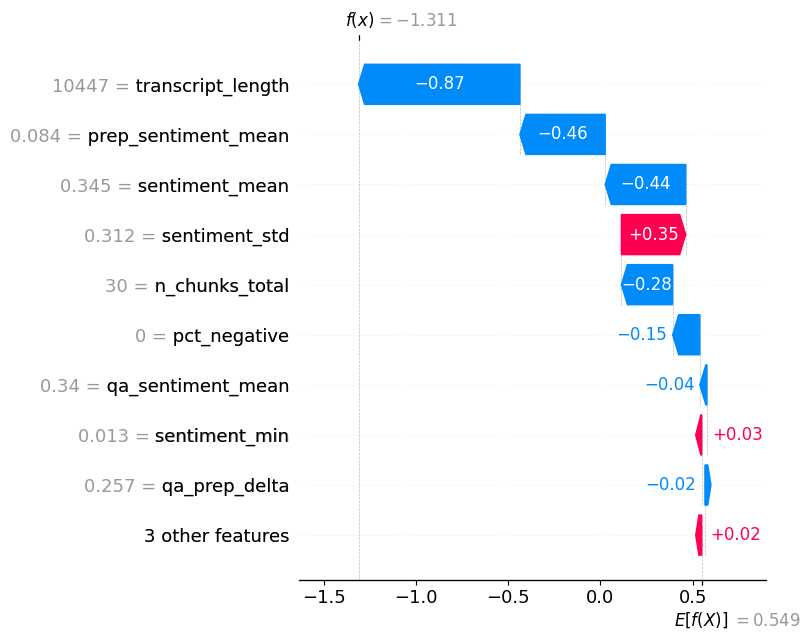

✓ Saved figures/shap_waterfall.png


In [28]:
# Pick first test sample -- change idx to explore other predictions
idx = 0
sample   = X_explain.iloc[[idx]]
y_actual = folds[-1]["y_test"].iloc[idx]
y_prob   = final_model.predict_proba(sample)[0, 1]

print(f"Sample index:   {idx}")
print(f"Actual outcome: {'Up ↑' if y_actual == 1 else 'Down ↓'}")
print(f"Predicted prob: {y_prob:.1%} probability of Up")
print(f"Prediction:     {'Up ↑' if y_prob >= 0.5 else 'Down ↓'}")
print(f"Correct:        {'✓' if (y_prob >= 0.5) == y_actual else '✗'}")

shap_exp = shap.Explanation(
    values      = shap_values[idx],
    base_values = expected_value,
    data        = X_explain.iloc[idx].values,
    feature_names = feature_cols,
)
shap.waterfall_plot(shap_exp, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved figures/shap_waterfall.png")


**What the SHAP ranking actually tells me.** The top feature by mean |SHAP| is `transcript_length` -- not a sentiment feature at all -- followed by `prep_sentiment_mean`, which the note in Section 4.4 already flags as unreliable for most rows because of the Q&A-splitter bug. Given that HD's transcripts are consistently long (roughly 9,000-10,000 words) and HD is 8-for-8 "up" in this sample (Section 6), the leading SHAP feature is plausibly standing in for "is this an HD transcript" rather than capturing anything about what was actually said on the call. That's not a knock on SHAP -- it did exactly its job and surfaced what the model is really using, which happens to be a data artifact rather than the sentiment signal this project set out to test. Before trusting these feature importances I'd want to: (1) fix the Q&A splitter, (2) expand past 5 tickers so ticker identity can't masquerade as a feature, and (3) re-run this section once 1 and 2 are addressed.


---
## Section 9 — Save Model Artifacts

Train a final model on **all available data** (not just the last fold) for use in  
the Streamlit dashboard.

In [29]:
X_all = merged_df[feature_cols]
y_all = merged_df["label_1d"]

final_clf = train_xgb(X_all, y_all)

# Save model
model_path = MODEL_DIR / "module1_xgb.pkl"
with open(model_path, "wb") as f:
    pickle.dump(final_clf, f)

# Save feature list — needed to reconstruct inputs at inference time
feat_path = MODEL_DIR / "module1_features.json"
with open(feat_path, "w") as f:
    json.dump(feature_cols, f, indent=2)

print(f"✓ Model saved:    {model_path.relative_to(ROOT)}")
print(f"✓ Features saved: {feat_path.relative_to(ROOT)}")

✓ Model saved:    models/module1_xgb.pkl
✓ Features saved: models/module1_features.json


### 9.1 Verify the saved model loads correctly

In [30]:
with open(MODEL_DIR / "module1_xgb.pkl", "rb") as f:
    loaded = pickle.load(f)

test_preds = loaded.predict_proba(X_all.iloc[:3])
print("Sample predictions from loaded model:")
print(pd.DataFrame(test_preds, columns=["P(Down)", "P(Up)"]).round(3))
print("\n✓ Model loads and predicts correctly")

Sample predictions from loaded model:
   P(Down)  P(Up)
0    0.208  0.792
1    0.591  0.409
2    0.165  0.835

✓ Model loads and predicts correctly


---
## Section 10 — Results Summary & Checklist

### 10.1 README-ready results table

In [31]:
mean_shap = np.abs(shap_values).mean(axis=0)
top3_idx  = np.argsort(mean_shap)[::-1][:3]

print("MODULE 1 RESULTS — EARNINGS SENTIMENT CLASSIFIER")
print("=" * 55)
print(f"  Dataset    : {len(merged_df)} earnings events, {merged_df['ticker'].nunique()} tickers")
print(f"  Date range : {merged_df['earnings_date'].min().date()} → {merged_df['earnings_date'].max().date()}")
print(f"  Features   : {len(feature_cols)} FinBERT sentiment features")
print(f"  Classifier : XGBoost (depth=3, n_estimators=100)")
print(f"  Validation : Walk-forward CV ({len(folds)} folds)")
print()
print(f"  {'Metric':<30} {'Value':>8}")
print("  " + "-"*40)
print(f"  {'Mean CV Accuracy':<30} {results_df['accuracy'].mean():>8.1%}")
print(f"  {'Mean CV ROC-AUC':<30} {results_df['roc_auc'].mean():>8.3f}")
print(f"  {'Baseline (always up)':<30} {always_up_acc:>8.1%}")
print(f"  {'Baseline (random)':<30} {random_acc:>8.1%}")
print()
print("  Top 3 SHAP Features:")
for rank, i in enumerate(top3_idx, 1):
    print(f"    {rank}. {feature_cols[i]:<28} (mean |SHAP| = {mean_shap[i]:.4f})")

MODULE 1 RESULTS — EARNINGS SENTIMENT CLASSIFIER
  Dataset    : 28 earnings events, 5 tickers
  Date range : 2023-01-24 → 2024-11-20
  Features   : 12 FinBERT sentiment features
  Classifier : XGBoost (depth=3, n_estimators=100)
  Validation : Walk-forward CV (4 folds)

  Metric                            Value
  ----------------------------------------
  Mean CV Accuracy                  65.0%
  Mean CV ROC-AUC                   0.667
  Baseline (always up)              60.7%
  Baseline (random)                 46.4%

  Top 3 SHAP Features:
    1. transcript_length            (mean |SHAP| = 0.6393)
    2. prep_sentiment_mean          (mean |SHAP| = 0.5181)
    3. sentiment_std                (mean |SHAP| = 0.3980)


### 10.2 Week 2 checklist

In [32]:
checks = {
    "FinBERT loaded successfully":          True,
    "All transcripts processed":            len(records) >= len(transcript_files) * 0.8,
    "Sentiment merged with targets":         len(merged_df) >= len(targets) * 0.7,
    "EDA charts saved":                      (FIGURES_DIR / "sentiment_distributions.png").exists(),
    "Walk-forward CV implemented":           len(folds) >= 3,
    "XGBoost trained and evaluated":         len(fold_results) >= 3,
    "SHAP values computed":                  shap_values is not None,
    "SHAP charts saved":                     (FIGURES_DIR / "shap_summary.png").exists(),
    "Model artifact saved":                  (MODEL_DIR / "module1_xgb.pkl").exists(),
    "Feature list saved":                    (MODEL_DIR / "module1_features.json").exists(),
    "module1_features.csv saved":            (PROCESSED_DIR / "module1_features.csv").exists(),
}

print("WEEK 2 CHECKLIST")
print("=" * 50)
all_pass = True
for item, status in checks.items():
    icon = "✓" if status else "✗"
    print(f"  [{icon}] {item}")
    if not status:
        all_pass = False

print()
if all_pass:
    print("✅  All checks pass — ready for Week 3 (GARCH + LSTM)!")
else:
    print("⚠️   Some checks failed — review the cells above.")

WEEK 2 CHECKLIST
  [✓] FinBERT loaded successfully
  [✓] All transcripts processed
  [✓] Sentiment merged with targets
  [✓] EDA charts saved
  [✓] Walk-forward CV implemented
  [✓] XGBoost trained and evaluated
  [✓] SHAP values computed
  [✓] SHAP charts saved
  [✓] Model artifact saved
  [✓] Feature list saved
  [✓] module1_features.csv saved

✅  All checks pass — ready for Week 3 (GARCH + LSTM)!


## Where this leaves Module 1

The pipeline runs end to end: FinBERT scores every transcript, features merge cleanly with return labels (28 of 28 events matched), walk-forward CV avoids look-ahead leakage, and the model edges out the naive baseline (65.0% vs 60.7%). That confirms the *methodology* is sound.

What it doesn't yet confirm is a real sentiment signal. The two biggest issues surfaced while building this notebook:

1. The Q&A/prepared-remarks splitter misfires on 24 of 28 transcripts (Section 4.4), which undermines the one feature this project was specifically built to test (`qa_prep_delta`).
2. The top SHAP feature (`transcript_length`) looks more like a ticker-identity proxy than a content signal, given only 5 tickers and one (HD) with a fully one-sided label distribution (Section 8).

Before Week 3, the more useful next step for Module 1 specifically is fixing the splitter and widening the ticker universe past 5, not tuning the classifier further. Module 2 (volatility forecasting) doesn't depend on any of this since it's price-only, so it can proceed independently.
